In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/EDA_DEAP.ipynb
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s20.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s17.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s31.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s14.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s32.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s28.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s24.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s18.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s22.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s02.dat
/kaggl

Found 32 subjects in /kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python


Extracting features: 100%|██████████| 32/32 [02:14<00:00,  4.21s/it]



X = (1280, 160)
Valence threshold = 3.08, pos_ratio = 0.502
Arousal threshold = 3.31, pos_ratio = 0.500

TASK: valence
  Fold 1/10 done
  Fold 2/10 done
  Fold 3/10 done
  Fold 4/10 done
  Fold 5/10 done
  Fold 6/10 done
  Fold 7/10 done
  Fold 8/10 done
  Fold 9/10 done
  Fold 10/10 done
  Held-out subject 0 done
  Held-out subject 1 done
  Held-out subject 2 done
  Held-out subject 3 done
  Held-out subject 4 done
  Held-out subject 5 done
  Held-out subject 6 done
  Held-out subject 7 done

----- valence | Subject-Dependent -----
        Model  Acc Mean  Acc Std  F1 Mean  F1 Std
      RBF SVM    0.6320   0.0303   0.6307  0.0310
          MLP    0.6258   0.0593   0.6244  0.0601
Random Forest    0.6234   0.0398   0.6223  0.0396
      XGBoost    0.6172   0.0380   0.6165  0.0379

----- valence | LOSO -----
        Model  Acc Mean  Acc Std  F1 Mean  F1 Std
          MLP    0.6094   0.1691   0.4833  0.1029
      RBF SVM    0.5875   0.1104   0.4469  0.0959
      XGBoost    0.5469   0.1086

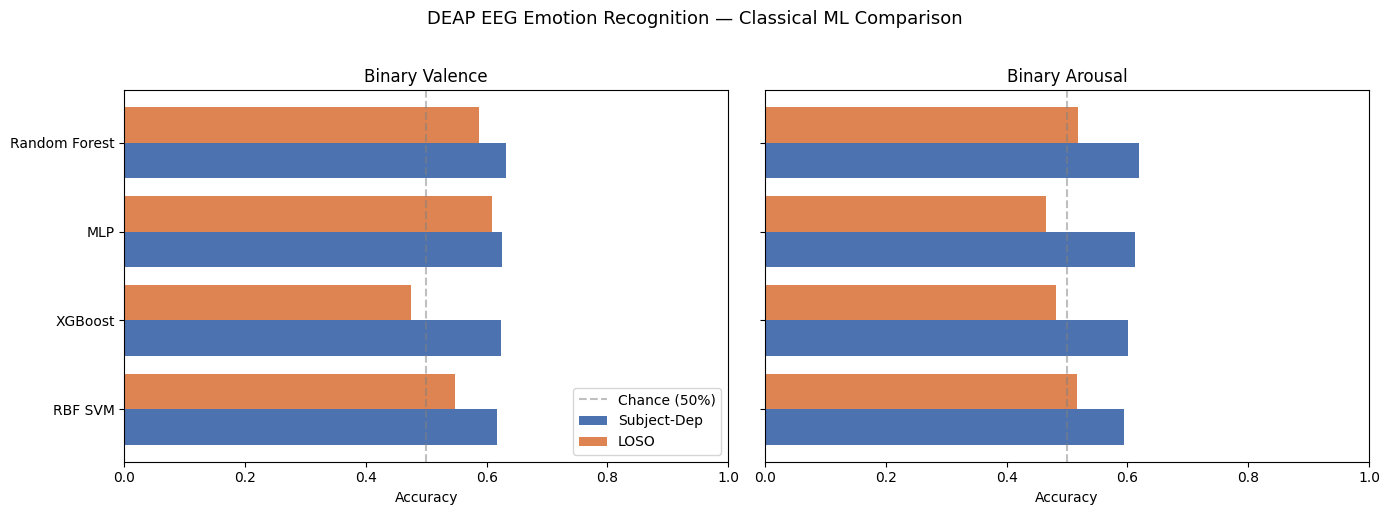

Saved: /kaggle/working/ml_comparison.png

CROSS-SUBJECT GAP (Subject-Dep − LOSO)
   Task         Model     SD   LOSO    Gap
valence       RBF SVM 0.6320 0.5875 0.0445
valence           MLP 0.6258 0.6094 0.0164
valence Random Forest 0.6234 0.4750 0.1484
valence       XGBoost 0.6172 0.5469 0.0703
arousal Random Forest 0.6188 0.5188 0.1000
arousal           MLP 0.6125 0.4656 0.1469
arousal       XGBoost 0.6016 0.4813 0.1203
arousal       RBF SVM 0.5945 0.5156 0.0789

Done. CSVs and plot saved to: /kaggle/working


In [1]:
"""
DEAP EEG Emotion Recognition - Classical ML (Binary Valence + Binary Arousal)
==============================================================================
CS471 Machine Learning - Semester Project

Two classification tasks:
  1. Binary Valence (positive vs negative)
  2. Binary Arousal (high vs low)

Labels binarized using MEDIAN SPLIT (not fixed threshold) to ensure
balanced classes and avoid majority-class collapse.

Four models: RBF SVM, Random Forest, XGBoost, MLP
Two protocols: Subject-Dependent (10-fold) + Leave-One-Subject-Out (8 subjects)

Drop into a single Kaggle cell after the starter cell.
"""

import os, pickle, time, warnings
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - skipping. `pip install xgboost`")

# ================== CONFIG ==================
DATA_DIR = "/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python"
OUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
LOSO_SUBJECTS = 8
N_FOLDS = 10
# ============================================

FS = 128
N_EEG = 32
BANDS = {"delta": (1, 4), "theta": (4, 8), "alpha": (8, 13),
         "beta": (13, 30), "gamma": (30, 45)}
STIM_START = 3 * FS


# ---------------- Feature extraction ----------------
def bandpass(sig, lo, hi, fs=FS, order=4):
    b, a = butter(order, [lo / (fs / 2), hi / (fs / 2)], btype="band")
    return filtfilt(b, a, sig, axis=-1)

def differential_entropy(sig):
    return 0.5 * np.log(2 * np.pi * np.e * (np.var(sig, axis=-1) + 1e-12))

def extract_trial_features(trial_eeg):
    sig = trial_eeg[:, STIM_START:]
    feats = [differential_entropy(bandpass(sig, lo, hi)) for (lo, hi) in BANDS.values()]
    return np.concatenate(feats)  # (160,)

def load_subject(path):
    with open(path, "rb") as f:
        d = pickle.load(f, encoding="latin1")
    return d["data"][:, :N_EEG, :], d["labels"]


def build_dataset(data_dir):
    """Extract features once, build binary valence and arousal labels using median split."""
    files = sorted(f for f in os.listdir(data_dir) if f.endswith(".dat"))
    print(f"Found {len(files)} subjects in {data_dir}")
    X, val_raw, aro_raw, groups = [], [], [], []
    for sid, fname in enumerate(tqdm(files, desc="Extracting features")):
        data, labels = load_subject(os.path.join(data_dir, fname))
        for trial in range(data.shape[0]):
            X.append(extract_trial_features(data[trial]))
            val_raw.append(labels[trial, 0])
            aro_raw.append(labels[trial, 1])
            groups.append(sid)

    X = np.asarray(X, dtype=np.float32)
    val_raw = np.asarray(val_raw)
    aro_raw = np.asarray(aro_raw)
    groups = np.asarray(groups)

    # MEDIAN SPLIT binarization — guarantees ~50/50 class balance
    val_thresh = np.median(val_raw)
    aro_thresh = np.median(aro_raw)
    y_valence = (val_raw >= val_thresh).astype(np.int64)
    y_arousal = (aro_raw >= aro_thresh).astype(np.int64)

    print(f"\nX = {X.shape}")
    print(f"Valence threshold = {val_thresh:.2f}, pos_ratio = {y_valence.mean():.3f}")
    print(f"Arousal threshold = {aro_thresh:.2f}, pos_ratio = {y_arousal.mean():.3f}")
    return X, y_valence, y_arousal, groups


# ---------------- Models ----------------
def get_models():
    models = {
        "RBF SVM":       SVC(C=1.0, kernel="rbf", gamma="scale", class_weight="balanced"),
        "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                random_state=42, class_weight="balanced"),
        "MLP":           MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                       random_state=42, early_stopping=True),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            eval_metric="logloss", n_jobs=-1, random_state=42)
    return models


# ---------------- Evaluation ----------------
def evaluate_fold(model, Xtr, ytr, Xte, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {"acc": accuracy_score(yte, pred),
            "f1":  f1_score(yte, pred, average="macro"),
            "time": time.time() - t0}


def subject_dependent(X, y, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = {name: [] for name in get_models()}
    for fold, (tr, te) in enumerate(skf.split(X, y)):
        sc = StandardScaler().fit(X[tr])
        Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        for name, model in get_models().items():
            results[name].append(evaluate_fold(model, Xtr, y[tr], Xte, y[te]))
        print(f"  Fold {fold+1}/{n_splits} done")
    return results


def loso(X, y, groups, max_subjects=8):
    logo = LeaveOneGroupOut()
    results = {name: [] for name in get_models()}
    for i, (tr, te) in enumerate(logo.split(X, y, groups)):
        if i >= max_subjects:
            break
        sc = StandardScaler().fit(X[tr])
        Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        for name, model in get_models().items():
            results[name].append(evaluate_fold(model, Xtr, y[tr], Xte, y[te]))
        print(f"  Held-out subject {groups[te][0]} done")
    return results


def summarize(results, label):
    rows = []
    for name, folds in results.items():
        accs = [f["acc"] for f in folds]
        f1s  = [f["f1"]  for f in folds]
        rows.append({"Model": name,
                     "Acc Mean": np.mean(accs), "Acc Std": np.std(accs),
                     "F1 Mean":  np.mean(f1s),  "F1 Std":  np.std(f1s)})
    df = pd.DataFrame(rows).sort_values("Acc Mean", ascending=False).reset_index(drop=True)
    print(f"\n----- {label} -----")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return df


def run_task(task_name, X, y, groups):
    print(f"\n{'='*60}")
    print(f"TASK: {task_name}")
    print(f"{'='*60}")
    sd_res   = subject_dependent(X, y, n_splits=N_FOLDS)
    loso_res = loso(X, y, groups, max_subjects=LOSO_SUBJECTS)
    sd_df    = summarize(sd_res,   f"{task_name} | Subject-Dependent")
    loso_df  = summarize(loso_res, f"{task_name} | LOSO")
    sd_df.to_csv(f"{OUT_DIR}/results_sd_{task_name}.csv", index=False)
    loso_df.to_csv(f"{OUT_DIR}/results_loso_{task_name}.csv", index=False)
    return sd_df, loso_df


def plot_comparison(all_results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, (task, (sd_df, loso_df)) in zip(axes, all_results.items()):
        merged = sd_df[["Model", "Acc Mean"]].rename(columns={"Acc Mean": "SD"})
        merged = merged.merge(
            loso_df[["Model", "Acc Mean"]].rename(columns={"Acc Mean": "LOSO"}),
            on="Model").sort_values("SD", ascending=True)
        y_pos = np.arange(len(merged))
        w = 0.4
        ax.barh(y_pos - w/2, merged["SD"],   w, label="Subject-Dep", color="#4C72B0")
        ax.barh(y_pos + w/2, merged["LOSO"], w, label="LOSO", color="#DD8452")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(merged["Model"])
        ax.set_title(f"Binary {task.capitalize()}")
        ax.set_xlim(0, 1)
        ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance (50%)")
        ax.set_xlabel("Accuracy")
    axes[0].legend(loc="lower right")
    plt.suptitle("DEAP EEG Emotion Recognition — Classical ML Comparison", fontsize=13, y=1.02)
    plt.tight_layout()
    out = f"{OUT_DIR}/ml_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


def gap_table(all_results):
    print(f"\n{'='*60}")
    print("CROSS-SUBJECT GAP (Subject-Dep − LOSO)")
    print(f"{'='*60}")
    rows = []
    for task, (sd_df, loso_df) in all_results.items():
        sd_m   = sd_df.set_index("Model")["Acc Mean"]
        loso_m = loso_df.set_index("Model")["Acc Mean"]
        for model in sd_m.index:
            rows.append({"Task": task, "Model": model,
                         "SD": sd_m[model], "LOSO": loso_m[model],
                         "Gap": sd_m[model] - loso_m[model]})
    gap_df = pd.DataFrame(rows)
    print(gap_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    gap_df.to_csv(f"{OUT_DIR}/cross_subject_gap.csv", index=False)


# ---------------- Run ----------------
X, y_val, y_aro, groups = build_dataset(DATA_DIR)

all_results = {}
all_results["valence"] = run_task("valence", X, y_val, groups)
all_results["arousal"] = run_task("arousal", X, y_aro, groups)

plot_comparison(all_results)
gap_table(all_results)
print("\nDone. CSVs and plot saved to:", OUT_DIR)